In [5]:
import geopandas as gpd
from pathlib import Path
from libpysal import weights
import matplotlib.pyplot as plt
import pandas as pd

# Leer cartografía
rm_comunas = gpd.read_file("datos/external/censo2017/R13/COMUNA_C17.shp") 
rm_comunas.head()

print(rm_comunas.crs)



EPSG:4674


In [6]:
rm_comunas = rm_comunas.to_crs(epsg=32719)
print(rm_comunas.crs)

EPSG:32719


In [8]:
rm_comunas.head()

,REGION,NOM_REGION,PROVINCIA,NOM_PROVIN,COMUNA,NOM_COMUNA,SHAPE_Leng,SHAPE_Area,geometry
0,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13404,PAINE,1.625330,0.066035,"POLYGON ((350033.920 6265707.472, 350106.705 6..."
1,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13402,BUIN,0.884164,0.021166,"POLYGON ((348666.339 6275861.274, 348652.409 6..."
2,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13124,PUDAHUEL,0.720176,0.019124,"POLYGON ((333540.425 6307203.281, 333624.972 6..."
3,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13103,CERRO NAVIA,0.170180,0.001076,"POLYGON ((340136.215 6301567.277, 340172.841 6..."
4,13,REGIÓN METROPOLITANA DE SANTIAGO,133,CHACABUCO,13301,COLINA,1.692007,0.093820,"POLYGON ((350790.367 6352972.781, 350751.311 6..."


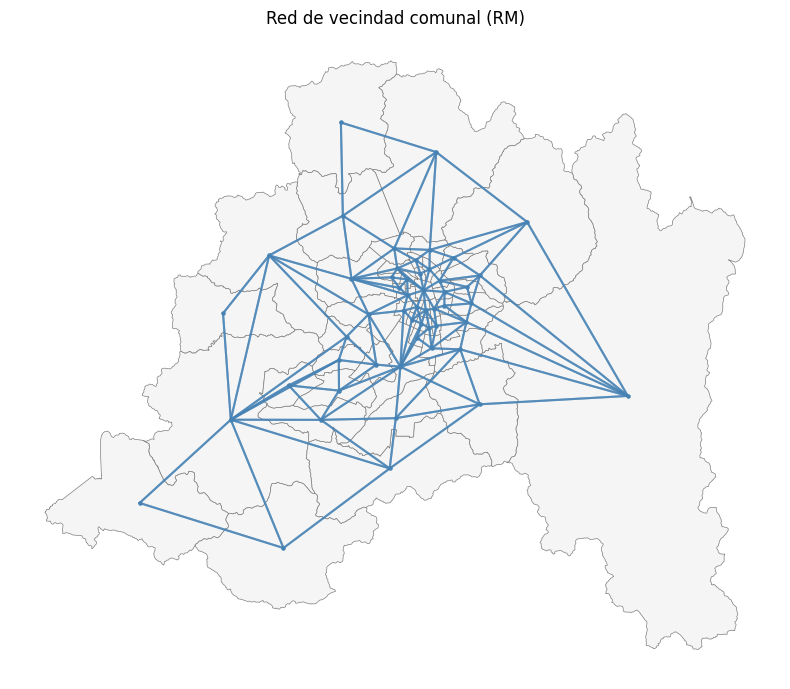

Nodos (comunas): 52
Grado promedio: 5.5
Islas (comunas aisladas): []


In [ ]:
# Construir pesos Queen
w_rm = weights.contiguity.Queen.from_dataframe(rm_comunas, ids="NOM_COMUNA")

# Establecer índice
rm_comunas_idx = rm_comunas.set_index("NOM_COMUNA")

# Visualizar
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
rm_comunas_idx.plot(ax=ax, edgecolor="grey", facecolor="whitesmoke", linewidth=0.5)
w_rm.plot(
    rm_comunas_idx,  # ← usar rm_comunas_idx, no rm_comunas
    ax=ax,
    edge_kws=dict(color="steelblue", linewidth=1.5, alpha=0.7),
    node_kws=dict(marker="o", color="steelblue", s=5),
)
ax.set_title("Red de vecindad comunal (RM)")
ax.set_axis_off()
plt.tight_layout()
plt.show()



In [14]:
# Estadísticas básicas
cardinalities = pd.Series(w_rm.cardinalities)
print(f"Nodos (comunas): {len(w_rm.neighbors)}")
print(f"Grado promedio: {cardinalities.mean():.1f}")
print(f"Islas (comunas aisladas): {w_rm.islands}")

Nodos (comunas): 52
Grado promedio: 5.5
Islas (comunas aisladas): []


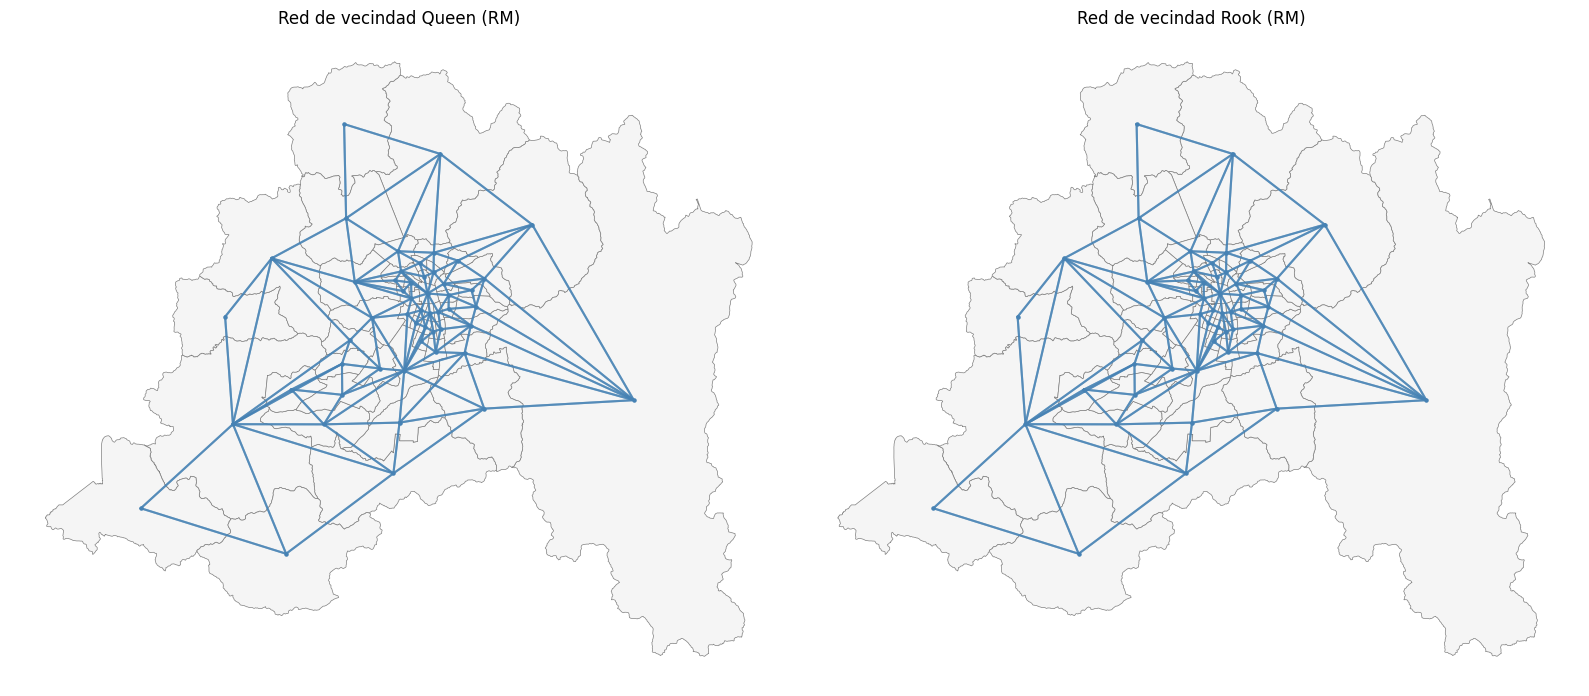


Queen:
  Grado promedio : 5.50
  Máximo vecinos : 12
  Mínimo vecinos : 2
  Islas          : []

Rook:
  Grado promedio : 5.35
  Máximo vecinos : 11
  Mínimo vecinos : 2
  Islas          : []


In [15]:
# =============================================
# EJERCICIO 1: Comparar Queen vs Rook para la RM
# =============================================
w_queen = weights.contiguity.Queen.from_dataframe(rm_comunas, ids="NOM_COMUNA")
w_rook = weights.contiguity.Rook.from_dataframe(rm_comunas, ids="NOM_COMUNA")

rm_comunas_idx = rm_comunas.set_index("NOM_COMUNA")

fig, axs = plt.subplots(1, 2, figsize=(16, 8))

for ax, w, titulo in zip(axs, [w_queen, w_rook], ["Queen", "Rook"]):
    rm_comunas_idx.plot(ax=ax, edgecolor="grey", facecolor="whitesmoke", linewidth=0.5)
    w.plot(
        rm_comunas_idx, ax=ax,
        edge_kws=dict(color="steelblue", linewidth=1.5, alpha=0.7),
        node_kws=dict(marker="o", color="steelblue", s=5),
    )
    ax.set_title(f"Red de vecindad {titulo} (RM)")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

# Comparar estadísticas
for nombre, w in [("Queen", w_queen), ("Rook", w_rook)]:
    card = pd.Series(w.cardinalities)
    print(f"\n{nombre}:")
    print(f"  Grado promedio : {card.mean():.2f}")
    print(f"  Máximo vecinos : {card.max()}")
    print(f"  Mínimo vecinos : {card.min()}")
    print(f"  Islas          : {w.islands}")

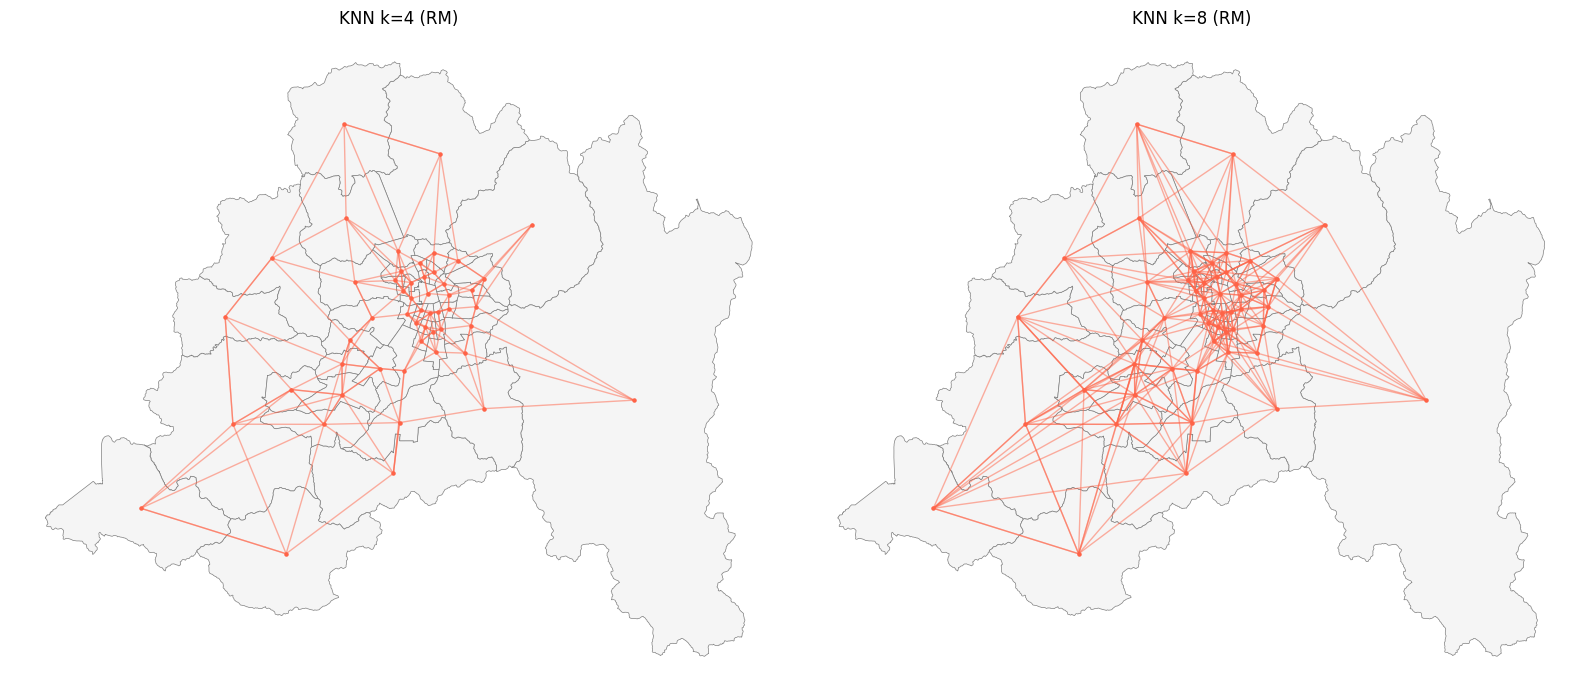


KNN k=4:
  Densidad : 7.69%
  Histograma : [(np.int64(4), np.int64(52))]

KNN k=8:
  Densidad : 15.38%
  Histograma : [(np.int64(8), np.int64(52))]


In [17]:
# =============================================
# EJERCICIO 2: Comparar KNN k=4 vs k=8
# =============================================
wk4 = weights.distance.KNN.from_dataframe(rm_comunas, k=4, ids="NOM_COMUNA")
wk8 = weights.distance.KNN.from_dataframe(rm_comunas, k=8, ids="NOM_COMUNA")

fig, axs = plt.subplots(1, 2, figsize=(16, 8))

for ax, w, k in zip(axs, [wk4, wk8], [4, 8]):
    rm_comunas_idx.plot(ax=ax, edgecolor="grey", facecolor="whitesmoke", linewidth=0.5)
    w.plot(
        rm_comunas_idx, ax=ax,
        edge_kws=dict(color="tomato", linewidth=1, alpha=0.5),
        node_kws=dict(marker="o", color="tomato", s=5),
    )
    ax.set_title(f"KNN k={k} (RM)")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

# Comparar densidad
for nombre, w in [("KNN k=4", wk4), ("KNN k=8", wk8)]:
    print(f"\n{nombre}:")
    print(f"  Densidad : {w.pct_nonzero:.2f}%")
    print(f"  Histograma : {w.histogram}")

Comuna con más vecinos: SAN BERNARDO (12 vecinos)
Sus vecinas: ['CALERA DE TANGO', 'TALAGANTE', 'LO ESPEJO', 'MAIPÚ', 'LA CISTERNA', 'PUENTE ALTO', 'PIRQUE', 'BUIN', 'CERRILLOS', 'ISLA DE MAIPO', 'LA PINTANA', 'EL BOSQUE']


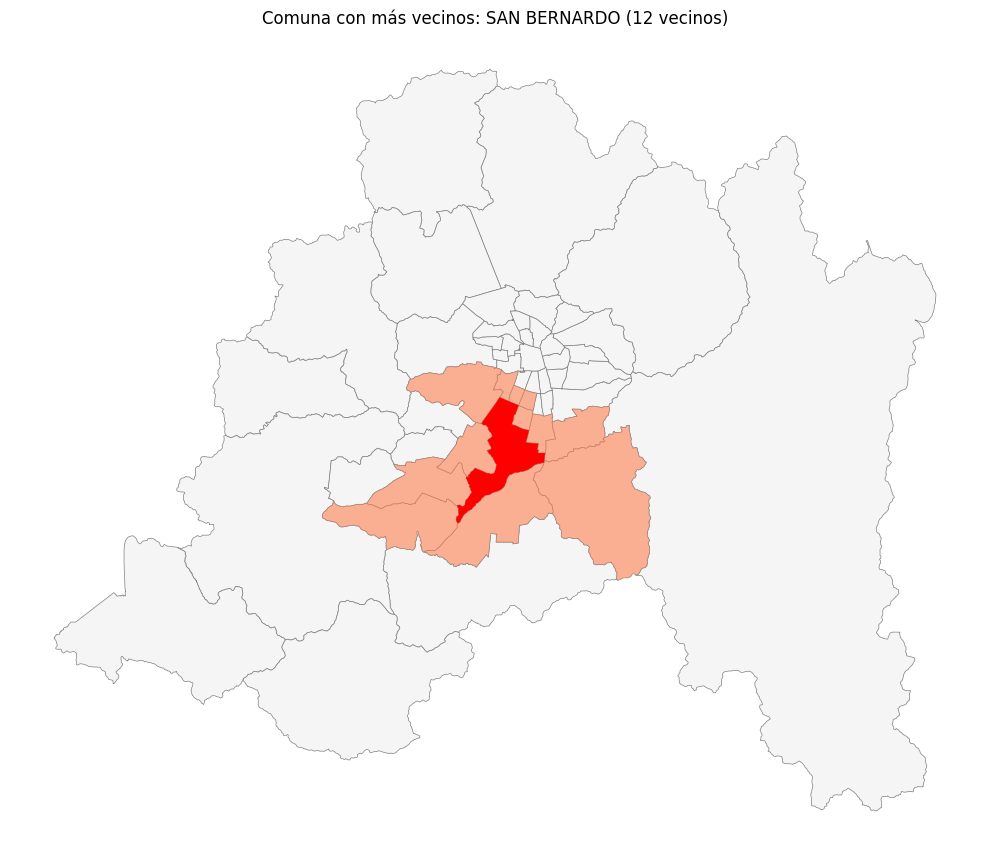

In [18]:
# =============================================
# EJERCICIO 3: Comuna con más vecinos
# =============================================
card_queen = pd.Series(w_queen.cardinalities)

# Identificar la comuna con más vecinos
comuna_max = card_queen.idxmax()
n_vecinos = card_queen.max()
vecinos = list(w_queen.neighbors[comuna_max])

print(f"Comuna con más vecinos: {comuna_max} ({n_vecinos} vecinos)")
print(f"Sus vecinas: {vecinos}")

# Visualizar destacada
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
rm_comunas_idx.plot(ax=ax, edgecolor="grey", facecolor="whitesmoke", linewidth=0.5)

# Colorear vecinas
rm_comunas_idx.loc[vecinos].plot(ax=ax, facecolor="coral", alpha=0.6)

# Colorear comuna focal
rm_comunas_idx.loc[[comuna_max]].plot(ax=ax, facecolor="red")

ax.set_title(f"Comuna con más vecinos: {comuna_max} ({n_vecinos} vecinos)")
ax.set_axis_off()
plt.tight_layout()
plt.show()